# Cell-Cell Communication in vWAT: Cleavage Machinery & Ligand-Receptor Scoring

> **Where this fits:** NB11 established the Fndc5/irisin autocrine loop in Areg cells.
> This notebook asks two follow-up questions:
> 1. **Does the cleavage machinery (ADAM10/17) support irisin secretion from Areg cells?**
>    Without a protease to shed Fndc5, the loop stays intracellular and non-functional.
> 2. **What is the broader communication landscape between Areg stromal cells and the
>    immune populations in vWAT?** Gemini's suggestion: check if Areg cells are talking to
>    macrophages and T-cells, which could explain the anti-inflammatory exercise effect.
>
> **Approach:** No CCC package is installed (LIANA/CellPhoneDB require additional deps).
> We use a manual scored approach: for each ligand-receptor pair, compute
> `score = mean_ligand_sender × mean_receptor_receiver` per condition, then compare
> TC vs SC delta. This is the same core calculation CellPhoneDB uses internally.
>
> **N caveat:** TC = 3 mice, SC = 3 mice. Scores are exploratory, not statistically tested.

## Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy.sparse import issparse

sc.settings.verbosity = 0

DATA_PATH = Path('/Users/jeffrey.katz/Documents/side-projects/bioml/mice-exercise/GSE183288_Single_cell_atlas.h5ad')
OUT_DIR   = Path('/Users/jeffrey.katz/Documents/side-projects/bioml/mice-exercise/python_pipeline/outputs')
OUT_DIR.mkdir(exist_ok=True)

FIG_DIR = OUT_DIR / 'nb12_figures'
FIG_DIR.mkdir(exist_ok=True)

In [2]:
adata = sc.read_h5ad(DATA_PATH)
print(f'Atlas: {adata.n_obs:,} cells x {adata.n_vars:,} genes')

vwat = adata[adata.obs['tissue'] == 'vWAT'].copy()
print(f'vWAT:  {vwat.n_obs:,} cells')
print(f'\nvWAT cell states (top 15):')
print(vwat.obs['cell_state_label'].value_counts().head(15).to_string())

Atlas: 204,883 cells x 17,341 genes
vWAT:  78,860 cells

vWAT cell states (top 15):
cell_state_label
CP            26001
WAT_IPC       15824
Areg           6197
NK             5498
pre_CP         4687
CD4_Memory     2559
Fibroblast     2358
cDC2           1808
nILC2          1703
Treg           1257
NKT            1218
Capillary      1188
M2             1172
Tgd_CD27-      1144
CD4_Naive      1132


---

## Section 1: ADAM protease expression — does the cleavage machinery support irisin secretion?

Fndc5 is a transmembrane protein; irisin is shed from its extracellular domain by ADAM10/17
(a disintegrin metalloproteinase). For the autocrine loop to be functional, Areg cells must
express the cleaving protease alongside Fndc5.

**Prediction if the loop is functional:**
- ADAM10 or ADAM17 present in Areg cells at baseline (constitutive expression is sufficient —
  substrate availability is the rate-limiting step, not protease abundance).
- If ADAM expression *also* increases with exercise alongside Fndc5, that's a stronger signal.

**What we already know from a quick lookup:**
```
                Adam10  Adam17  Adam12  Adam9  Fndc5
SC (lean sed)    0.103   0.135   0.072  0.182  0.024
SH (obese sed)   0.126   0.153   0.087  0.239  0.014
TC (lean ex)     0.099   0.104   0.060  0.167  0.063  ← Fndc5 triples
TH (obese ex)    0.100   0.096   0.060  0.192  0.021
```
Adam10/17 are constitutively expressed; Fndc5 is the regulated substrate.

In [3]:
ADAM_GENES = ['Adam10', 'Adam17', 'Adam12', 'Adam9']
adam_present = [g for g in ADAM_GENES if g in vwat.var_names]

areg_vwat = vwat[vwat.obs['cell_state_label'] == 'Areg']
print(f'Areg cells in vWAT: {areg_vwat.n_obs:,}')

adam_df = sc.get.obs_df(areg_vwat, keys=adam_present + ['Fndc5', 'intervention_group'])
adam_summary = adam_df.groupby('intervention_group')[adam_present + ['Fndc5']].mean().round(3)
adam_summary.index.name = 'condition'
print('\nMean log-normalized expression in vWAT Areg cells:')
print(adam_summary.to_string())

Areg cells in vWAT: 6,197

Mean log-normalized expression in vWAT Areg cells:
           Adam10  Adam17  Adam12  Adam9  Fndc5
condition                                      
SC          0.103   0.135   0.072  0.182  0.024
SH          0.126   0.153   0.087  0.239  0.014
TC          0.099   0.104   0.060  0.167  0.063
TH          0.100   0.096   0.060  0.192  0.021


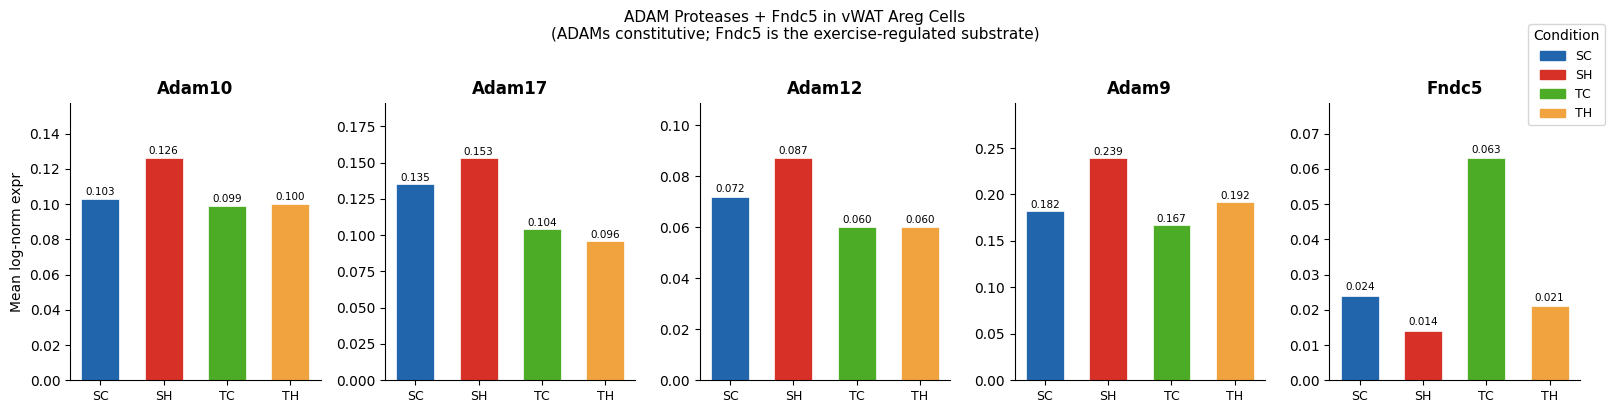

Saved.


In [4]:
# Visualize: side-by-side bar chart for ADAM proteases + Fndc5 in Areg cells.
# Goal: show ADAMs are constitutive while Fndc5 is the exercise-regulated substrate.

COND_ORDER  = ['SC', 'SH', 'TC', 'TH']
COND_COLORS = {'SC': '#2166AC', 'SH': '#D73027', 'TC': '#4DAC26', 'TH': '#F1A340'}

plot_genes = adam_present + ['Fndc5']
adam_plot  = adam_summary.loc[COND_ORDER, plot_genes]

fig, axes = plt.subplots(1, len(plot_genes), figsize=(3.2 * len(plot_genes), 4), sharey=False)

for ax, gene in zip(axes, plot_genes):
    vals   = adam_plot[gene]
    colors = [COND_COLORS[c] for c in COND_ORDER]
    bars   = ax.bar(COND_ORDER, vals, color=colors, width=0.6, edgecolor='white', linewidth=0.5)
    ax.set_title(gene, fontsize=12, fontweight='bold')
    ax.set_ylim(0, vals.max() * 1.25)
    ax.set_ylabel('Mean log-norm expr' if ax == axes[0] else '')
    ax.tick_params(axis='x', labelsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)

legend_patches = [mpatches.Patch(color=COND_COLORS[c], label=c) for c in COND_ORDER]
fig.legend(handles=legend_patches, loc='upper right', title='Condition',
           bbox_to_anchor=(1.01, 1), fontsize=9)
fig.suptitle('ADAM Proteases + Fndc5 in vWAT Areg Cells\n'
             '(ADAMs constitutive; Fndc5 is the exercise-regulated substrate)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'adam_fndc5_areg_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

In [5]:
# Compare ADAM expression in Areg vs other major vWAT stromal states.
# Provides context: is Areg's ADAM level high or low relative to neighboring cells?

STROMAL_STATES = ['Areg', 'CP', 'WAT_IPC', 'pre_CP', 'Fibroblast']
stromal = vwat[vwat.obs['cell_state_label'].isin(STROMAL_STATES)]

adam_across_states = sc.get.obs_df(
    stromal, keys=adam_present + ['Fndc5', 'cell_state_label']
).groupby('cell_state_label')[adam_present + ['Fndc5']].mean().round(3)

print('Mean expression across vWAT stromal states (all conditions pooled):')
print(adam_across_states.to_string())

Mean expression across vWAT stromal states (all conditions pooled):
                  Adam10  Adam17  Adam12  Adam9  Fndc5
cell_state_label                                      
Areg               0.105   0.118   0.068  0.193  0.030
CP                 0.098   0.133   0.204  0.179  0.106
Fibroblast         0.187   0.069   0.002  0.104  0.003
WAT_IPC            0.169   0.159   0.023  0.276  0.002
pre_CP             0.128   0.165   0.123  0.248  0.016


---

## Section 2: Manual Ligand-Receptor Scoring Framework

**Method:** For each (ligand, receptor) pair and each (sender, receiver, condition) triplet:
```
score = mean_expr(ligand in sender cells) × mean_expr(receptor in receiver cells)
```
This is equivalent to the geometric-mean interaction score used in CellPhoneDB v2/v3.
We then compute `delta = score_TC − score_SC` to identify exercise-responsive interactions.

**LR pairs selected:** 25 biologically motivated pairs covering:
- Irisin autocrine (Fndc5 → Itgb5/Itgav/Itgb1)
- Amphiregulin paracrine (Areg → Egfr/Erbb2/Erbb3)
- ILC2 activation (Il33 → Il1rl1; Tslp → Crlf2)
- Immunomodulation (Tgfb1/2 → Tgfbr; Ccl2 → Ccr2; Csf1 → Csf1r)
- Stromal signaling (Pdgf, Wnt, Notch, VEGF, Il6, Tnf)

In [6]:
LR_PAIRS = [
    # (ligand, receptor, pathway_label)
    ('Fndc5',  'Itgb5',   'Irisin-autocrine'),
    ('Fndc5',  'Itgav',   'Irisin-autocrine'),
    ('Fndc5',  'Itgb1',   'Irisin-autocrine'),
    ('Areg',   'Egfr',    'Amphiregulin'),
    ('Areg',   'Erbb2',   'Amphiregulin'),
    ('Areg',   'Erbb3',   'Amphiregulin'),
    ('Il33',   'Il1rl1',  'ILC2-activation'),
    ('Tslp',   'Crlf2',   'ILC2-activation'),
    ('Tgfb1',  'Tgfbr1',  'TGFb-immunosup'),
    ('Tgfb1',  'Tgfbr2',  'TGFb-immunosup'),
    ('Tgfb2',  'Tgfbr1',  'TGFb-immunosup'),
    ('Ccl2',   'Ccr2',    'Macrophage-recruit'),
    ('Cxcl12', 'Cxcr4',   'CXCL12-homing'),
    ('Csf1',   'Csf1r',   'Macrophage-recruit'),
    ('Vegfa',  'Kdr',     'Angiogenesis'),
    ('Vegfa',  'Flt1',    'Angiogenesis'),
    ('Pdgfa',  'Pdgfra',  'Stromal-PDGF'),
    ('Pdgfb',  'Pdgfrb',  'Stromal-PDGF'),
    ('Wnt5a',  'Fzd4',    'Wnt'),
    ('Wnt5a',  'Ror2',    'Wnt'),
    ('Il6',    'Il6st',   'IL6'),
    ('Il6',    'Il6ra',   'IL6'),
    ('Tnf',    'Tnfrsf1a','TNF'),
    ('Dll1',   'Notch1',  'Notch'),
    ('Jag1',   'Notch2',  'Notch'),
]

# Validate
valid = [(l, r, p) for l, r, p in LR_PAIRS
         if l in vwat.var_names and r in vwat.var_names]
print(f'{len(valid)}/{len(LR_PAIRS)} pairs have both genes in atlas')

25/25 pairs have both genes in atlas


In [7]:
def mean_expr(adata_sub, gene):
    """Mean log-normalized expression of gene across cells in adata_sub."""
    if gene not in adata_sub.var_names:
        return 0.0
    idx = adata_sub.var_names.get_loc(gene)
    x   = adata_sub.X[:, idx]
    if issparse(x):
        x = x.toarray().ravel()
    else:
        x = np.asarray(x).ravel()
    return float(x.mean())


def compute_lr_scores(adata_tissue, lr_pairs, conditions=None):
    """
    Compute mean(ligand_sender) × mean(receptor_receiver) for every
    (sender, receiver, condition, ligand, receptor) combination.
    Returns a long-format DataFrame.
    """
    cell_states = sorted(adata_tissue.obs['cell_state_label'].unique())
    if conditions is None:
        conditions = sorted(adata_tissue.obs['intervention_group'].unique())

    rows = []
    for cond in conditions:
        cond_data = adata_tissue[adata_tissue.obs['intervention_group'] == cond]
        # Pre-cache mean expression per gene per cell state
        cache = {}
        for state in cell_states:
            state_data = cond_data[cond_data.obs['cell_state_label'] == state]
            if state_data.n_obs == 0:
                continue
            all_lr_genes = list(set(g for l, r, _ in lr_pairs for g in (l, r)))
            for gene in all_lr_genes:
                cache[(state, gene)] = mean_expr(state_data, gene)

        for lig, rec, pathway in lr_pairs:
            for sender in cell_states:
                if (sender, lig) not in cache:
                    continue
                for receiver in cell_states:
                    if (receiver, rec) not in cache:
                        continue
                    score = cache[(sender, lig)] * cache[(receiver, rec)]
                    rows.append({
                        'condition': cond,
                        'sender':    sender,
                        'receiver':  receiver,
                        'ligand':    lig,
                        'receptor':  rec,
                        'pathway':   pathway,
                        'score':     score,
                    })
    return pd.DataFrame(rows)


print('Computing LR scores for SC and TC...')
lr_scores = compute_lr_scores(vwat, valid, conditions=['SC', 'TC'])
print(f'Rows: {len(lr_scores):,}  (sender × receiver × LR pair × condition)')
lr_scores.head(3)

Computing LR scores for SC and TC...
Rows: 59,525  (sender × receiver × LR pair × condition)


,condition,sender,receiver,ligand,receptor,pathway,score
0,SC,Areg,Areg,Fndc5,Itgb5,Irisin-autocrine,0.011765
1,SC,Areg,B_Fo,Fndc5,Itgb5,Irisin-autocrine,0.000000
2,SC,Areg,CD4_Memory,Fndc5,Itgb5,Irisin-autocrine,0.000000


In [8]:
# Pivot to compute delta (TC - SC) for every (sender, receiver, LR pair)
lr_pivot = lr_scores.pivot_table(
    index=['sender', 'receiver', 'ligand', 'receptor', 'pathway'],
    columns='condition',
    values='score'
).reset_index()

lr_pivot['delta_TC_SC'] = lr_pivot['TC'] - lr_pivot['SC']
lr_pivot['pct_change']  = ((lr_pivot['TC'] - lr_pivot['SC']) /
                           (lr_pivot['SC'] + 1e-8) * 100).round(1)

# Save full table
lr_pivot.to_csv(OUT_DIR / 'lr_scores_vwat_SC_TC.csv', index=False)
print(f'Full LR table saved: {len(lr_pivot):,} rows')
print(lr_pivot.sort_values('delta_TC_SC', ascending=False).head(5).to_string())

Full LR table saved: 30,625 rows
condition           sender             receiver  ligand receptor          pathway        SC        TC  delta_TC_SC    pct_change
19864      Non_Myelinating        SMC_precursor   Pdgfa   Pdgfra     Stromal-PDGF  0.000000  1.307872     1.307872  1.307872e+10
24177                 Treg      Non_Myelinating    Areg    Erbb3     Amphiregulin  0.722316  1.722399     1.000083  1.385000e+02
28552                nILC2      Non_Myelinating    Areg    Erbb3     Amphiregulin  0.777935  1.597535     0.819601  1.054000e+02
21455        SMC_precursor  Monocyte_Patrolling  Cxcl12    Cxcr4    CXCL12-homing  0.375194  1.099658     0.724464  1.931000e+02
9160            Fibroblast                 Mast    Il33   Il1rl1  ILC2-activation  0.667975  1.291533     0.623558  9.340000e+01


---

## Section 3: Areg as sender — who does it talk to?

Focus on Areg stromal cells as the sending population (they express the ligands).
Which receiver cell types show the largest exercise-driven increase in LR score?

In [9]:
# Filter to Areg as sender
areg_as_sender = lr_pivot[lr_pivot['sender'] == 'Areg'].copy()

# Top interactions by absolute delta
top_areg = (
    areg_as_sender
    .sort_values('delta_TC_SC', ascending=False)
    .head(20)[['receiver', 'ligand', 'receptor', 'pathway', 'SC', 'TC', 'delta_TC_SC']]
)
print('Top 20 Areg-as-sender interactions by exercise delta (TC - SC):')
print(top_areg.to_string(index=False))

Top 20 Areg-as-sender interactions by exercise delta (TC - SC):
             receiver ligand receptor            pathway       SC       TC  delta_TC_SC
  Monocyte_Patrolling Cxcl12    Cxcr4      CXCL12-homing 0.512748 0.863182     0.350434
                   M1 Cxcl12    Cxcr4      CXCL12-homing 0.332227 0.569097     0.236871
                 Mast   Il33   Il1rl1    ILC2-activation 0.127911 0.341189     0.213278
Monocyte_Inflammatory Cxcl12    Cxcr4      CXCL12-homing 0.371428 0.546171     0.174743
        CD8_Cytotoxic Cxcl12    Cxcr4      CXCL12-homing 0.258397 0.419581     0.161185
            Tgd_CD27+ Cxcl12    Cxcr4      CXCL12-homing 0.314923 0.473544     0.158621
         Large_vessel  Wnt5a     Fzd4                Wnt 0.012006 0.165717     0.153711
                  NKT Cxcl12    Cxcr4      CXCL12-homing 0.301248 0.453849     0.152600
           CD4_Memory Cxcl12    Cxcr4      CXCL12-homing 0.224325 0.370621     0.146297
                   NK Cxcl12    Cxcr4      CXCL12-homing

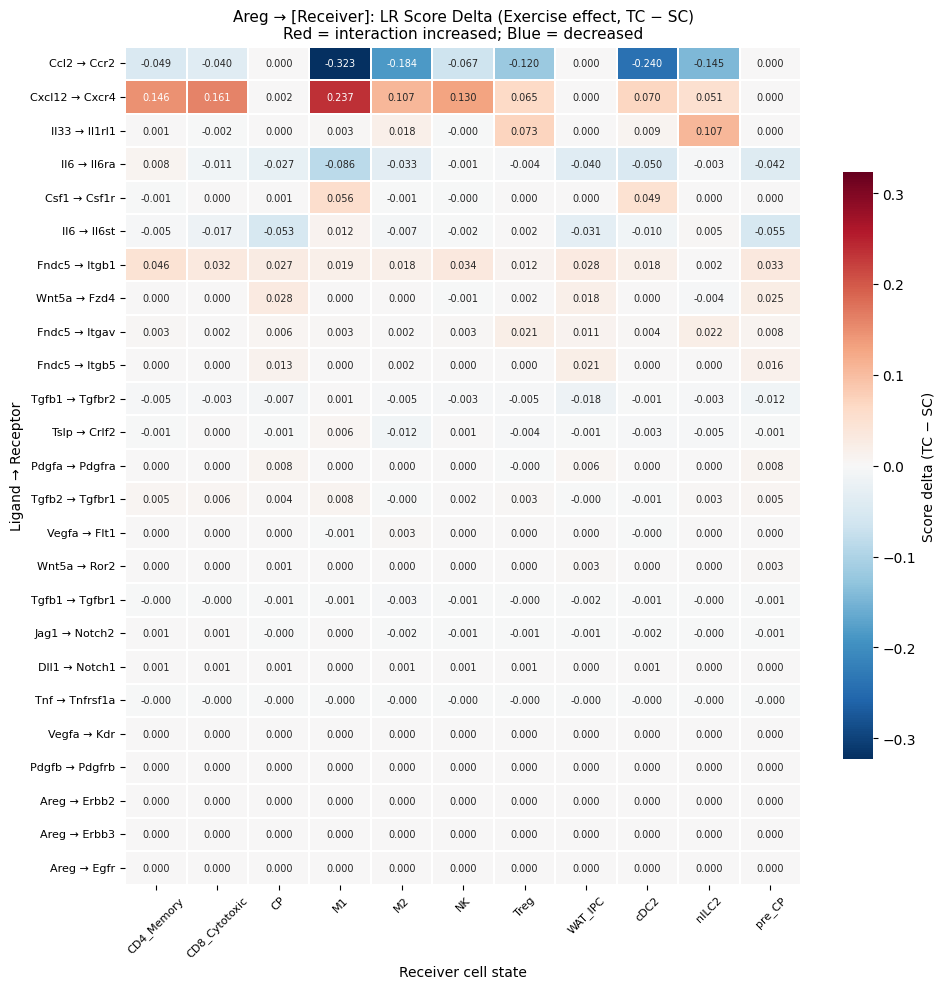

Saved.


In [10]:
# Heatmap: for key receiver cell types, show delta score per LR pair.
# Positive (red) = interaction strengthened by exercise.
# Negative (blue) = interaction weakened.

KEY_RECEIVERS = ['nILC2', 'Treg', 'M2', 'M1', 'NK', 'CP', 'WAT_IPC', 'pre_CP',
                 'CD4_Memory', 'CD8_Cytotoxic', 'cDC2', 'Macrophage']
key_receivers_present = [r for r in KEY_RECEIVERS
                         if r in vwat.obs['cell_state_label'].values]

# Build LR label
areg_as_sender['lr_label'] = (areg_as_sender['ligand'] + ' → ' +
                               areg_as_sender['receptor'])

hm_data = areg_as_sender[
    areg_as_sender['receiver'].isin(key_receivers_present)
].pivot_table(
    index='lr_label',
    columns='receiver',
    values='delta_TC_SC',
    aggfunc='sum'
).fillna(0)

# Sort rows by max absolute delta
hm_data = hm_data.loc[hm_data.abs().max(axis=1).sort_values(ascending=False).index]

vmax = hm_data.abs().values.max()

fig, ax = plt.subplots(figsize=(max(8, len(hm_data.columns) * 0.9),
                                max(6, len(hm_data) * 0.4)))
sns.heatmap(
    hm_data,
    ax=ax,
    cmap='RdBu_r',
    center=0,
    vmin=-vmax, vmax=vmax,
    annot=True, fmt='.3f',
    annot_kws={'size': 7},
    linewidths=0.3,
    cbar_kws={'label': 'Score delta (TC − SC)', 'shrink': 0.7}
)
ax.set_title('Areg → [Receiver]: LR Score Delta (Exercise effect, TC − SC)\n'
             'Red = interaction increased; Blue = decreased',
             fontsize=11)
ax.set_xlabel('Receiver cell state', fontsize=10)
ax.set_ylabel('Ligand → Receptor', fontsize=10)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'areg_sender_lr_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

---

## Section 4: Amphiregulin (Areg gene) → EGFR axis

The Areg cell state is named after amphiregulin — cells that express the *Areg* gene.
Amphiregulin signals through EGFR (Egfr/Erbb2/Erbb3). Key question: **which cell types
in vWAT express EGFR, and does the Areg→EGFR interaction change with exercise?**

This matters because amphiregulin→EGFR is a known tissue-repair and immune-regulation
axis: Tregs in adipose tissue use amphiregulin to promote tissue homeostasis.

In [11]:
# EGFR family expression per vWAT cell state (SC vs TC)
egfr_genes = [g for g in ['Egfr', 'Erbb2', 'Erbb3'] if g in vwat.var_names]

egfr_df = sc.get.obs_df(
    vwat, keys=egfr_genes + ['Areg', 'cell_state_label', 'intervention_group']
)

# Mean per cell_state × condition
egfr_means = (
    egfr_df[egfr_df['intervention_group'].isin(['SC', 'TC'])]
    .groupby(['cell_state_label', 'intervention_group'])[egfr_genes + ['Areg']]
    .mean()
    .round(3)
)

# Focus on Egfr (primary receptor)
egfr_pivot = egfr_means['Egfr'].unstack('intervention_group').fillna(0)
egfr_pivot['delta'] = egfr_pivot.get('TC', 0) - egfr_pivot.get('SC', 0)
egfr_pivot = egfr_pivot.sort_values('Egfr' if 'Egfr' in egfr_pivot.columns else 'TC',
                                     ascending=False)

print('Egfr mean expression per vWAT cell state (SC and TC):')
print(egfr_pivot.to_string())

Egfr mean expression per vWAT cell state (SC and TC):
intervention_group        SC   SH     TC   TH  delta
cell_state_label                                    
CP                     0.853  0.0  0.853  0.0  0.000
pre_CP                 0.798  0.0  0.666  0.0 -0.132
Areg                   0.540  0.0  0.518  0.0 -0.022
WAT_IPC                0.505  0.0  0.447  0.0 -0.058
Fibroblast             0.130  0.0  0.079  0.0 -0.051
Large_artery           0.000  0.0  0.064  0.0  0.064
Pericyte               0.178  0.0  0.038  0.0 -0.140
Capillary              0.150  0.0  0.031  0.0 -0.119
Epi                    0.047  0.0  0.021  0.0 -0.026
Mast                   0.051  0.0  0.004  0.0 -0.047
cDC2                   0.000  0.0  0.000  0.0  0.000
mo-DC                  0.000  0.0  0.000  0.0  0.000
cDC1                   0.000  0.0  0.000  0.0  0.000
Neutrophil             0.000  0.0  0.000  0.0  0.000
nILC2                  0.000  0.0  0.000  0.0  0.000
Treg                   0.000  0.0  0.000  0.0

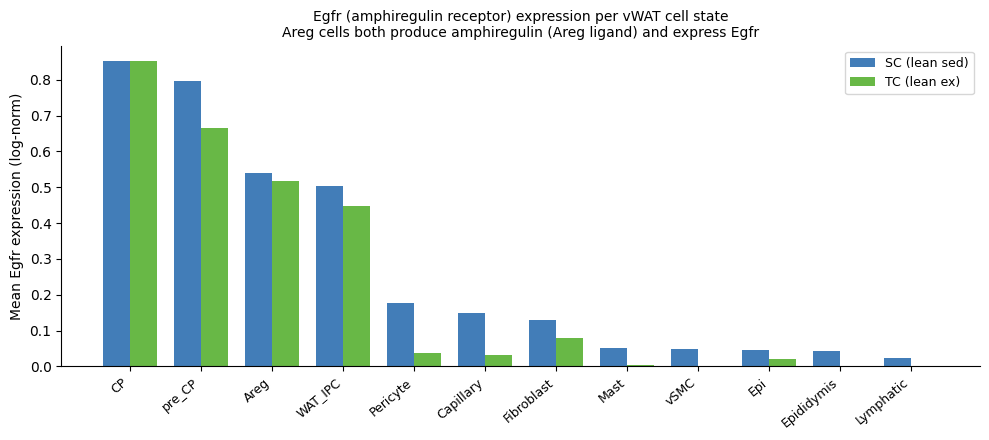


Areg cell state — Areg ligand + Egfr receptor expression by condition:
                    Areg    Egfr
intervention_group              
SC                   0.0  0.5395
SH                   0.0  0.4767
TC                   0.0  0.5184
TH                   0.0  0.5222


In [12]:
# Bar chart: top 12 EGFR-expressing states, SC vs TC
top_egfr_states = egfr_pivot.nlargest(12, 'SC').index.tolist()

fig, ax = plt.subplots(figsize=(10, 4.5))
x      = np.arange(len(top_egfr_states))
width  = 0.38

sc_vals = [egfr_pivot.loc[s, 'SC'] if 'SC' in egfr_pivot.columns else 0
           for s in top_egfr_states]
tc_vals = [egfr_pivot.loc[s, 'TC'] if 'TC' in egfr_pivot.columns else 0
           for s in top_egfr_states]

ax.bar(x - width/2, sc_vals, width, label='SC (lean sed)', color='#2166AC', alpha=0.85)
ax.bar(x + width/2, tc_vals, width, label='TC (lean ex)',  color='#4DAC26', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(top_egfr_states, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Mean Egfr expression (log-norm)')
ax.set_title('Egfr (amphiregulin receptor) expression per vWAT cell state\n'
             'Areg cells both produce amphiregulin (Areg ligand) and express Egfr',
             fontsize=10)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'egfr_by_cell_state.png', dpi=150, bbox_inches='tight')
plt.show()

# Also check: does Areg cell express both the ligand (Areg) and receptor (Egfr)?
areg_egfr = egfr_df[egfr_df['cell_state_label'] == 'Areg']
print('\nAreg cell state — Areg ligand + Egfr receptor expression by condition:')
print(areg_egfr.groupby('intervention_group')[['Areg', 'Egfr']].mean().round(4).to_string())

---

## Section 5: ILC2 activation axis (Il33 → nILC2)

The atlas contains 1,703 nILC2 cells in vWAT — a notable immune population.
ILC2s are activated by alarmins (IL-33, TSLP) released by stressed/damaged stromal cells.
Activated ILC2s in adipose tissue promote a type-2 immune environment that supports
adipogenesis and reduces inflammation.

**The question:** does exercise shift the Il33→Il1rl1 (ST2) or Tslp→Crlf2 signals?
Which cells produce the alarmins, and does exercise regulate this?

In [13]:
# Il33 expression across vWAT cell states — who's the alarmin source?
ilc2_genes = [g for g in ['Il33', 'Il1rl1', 'Tslp', 'Crlf2'] if g in vwat.var_names]

ilc2_df = sc.get.obs_df(
    vwat, keys=ilc2_genes + ['cell_state_label', 'intervention_group']
)

il33_by_state = (
    ilc2_df[ilc2_df['intervention_group'].isin(['SC', 'TC'])]
    .groupby(['cell_state_label', 'intervention_group'])[ilc2_genes]
    .mean().round(4)
)

# Top Il33-expressing states
if 'Il33' in ilc2_genes:
    il33_sc = il33_by_state['Il33'].unstack().fillna(0)
    print('Top Il33 producers in vWAT (mean log-norm, SC | TC):')
    print(il33_sc.nlargest(10, 'SC' if 'SC' in il33_sc.columns else il33_sc.columns[0]).to_string())

# Il1rl1 (ST2) = ILC2 receptor for IL-33
if 'Il1rl1' in ilc2_genes:
    print('\nIl1rl1 (ST2) expression in key immune states:')
    il1rl1 = il33_by_state['Il1rl1'].unstack().fillna(0)
    states_of_interest = [s for s in ['nILC2', 'Treg', 'CD4_Memory', 'M2', 'NK', 'Mast']
                          if s in il1rl1.index]
    print(il1rl1.loc[states_of_interest].to_string())

Top Il33 producers in vWAT (mean log-norm, SC | TC):
intervention_group      SC   SH      TC   TH
cell_state_label                            
SMC_precursor       0.8079  0.0  0.3737  0.0
Fibroblast          0.4352  0.0  0.5692  0.0
Areg                0.0833  0.0  0.1504  0.0
WAT_IPC             0.0693  0.0  0.0757  0.0
Large_vessel        0.0371  0.0  0.1186  0.0
pre_CP              0.0133  0.0  0.0072  0.0
Lymphatic           0.0065  0.0  0.0540  0.0
CP                  0.0046  0.0  0.0034  0.0
B_Fo                0.0000  0.0  0.0000  0.0
CD4_Memory          0.0000  0.0  0.0000  0.0

Il1rl1 (ST2) expression in key immune states:
intervention_group      SC   SH      TC   TH
cell_state_label                            
nILC2               1.7836  0.0  1.6991  0.0
Treg                1.6074  0.0  1.3737  0.0
CD4_Memory          0.0384  0.0  0.0299  0.0
M2                  0.1694  0.0  0.2150  0.0
NK                  0.0096  0.0  0.0027  0.0
Mast                1.5348  0.0  2.2692  0.0


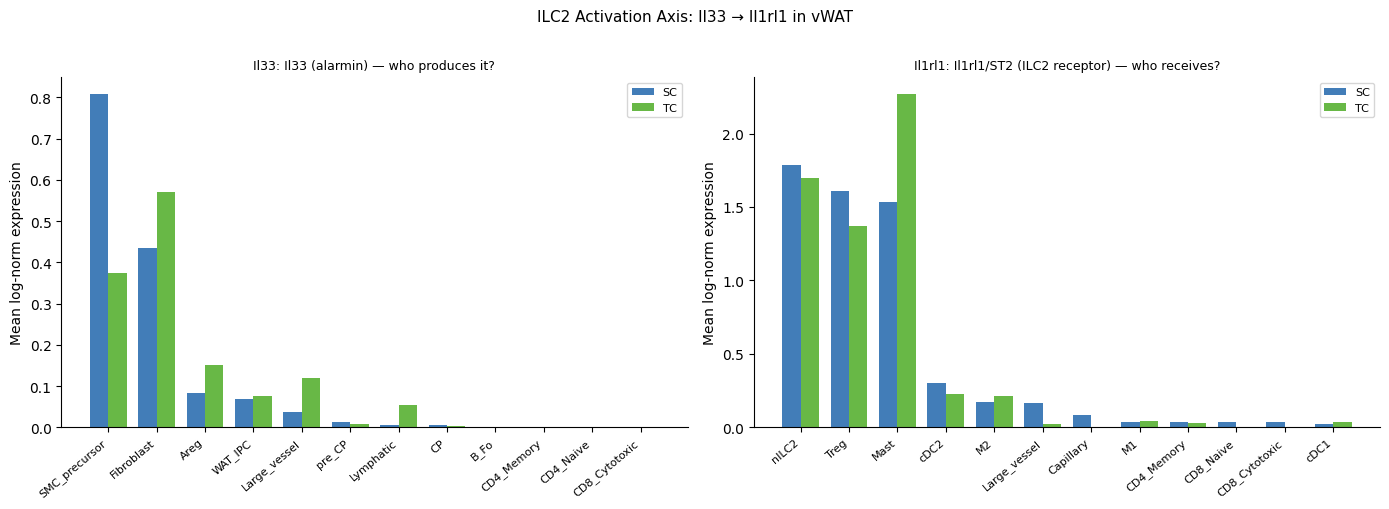

In [14]:
# Visualize the Il33 sender landscape and Il1rl1 receiver landscape
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, gene, title in zip(
    axes,
    ['Il33', 'Il1rl1'],
    ['Il33 (alarmin) — who produces it?', 'Il1rl1/ST2 (ILC2 receptor) — who receives?']
):
    if gene not in ilc2_genes:
        ax.text(0.5, 0.5, f'{gene} not in atlas', ha='center', va='center')
        continue
    pivot = il33_by_state[gene].unstack('intervention_group').fillna(0)
    top_states = pivot.nlargest(12, 'SC' if 'SC' in pivot.columns else pivot.columns[0]).index
    pivot_top = pivot.loc[top_states]

    x = np.arange(len(top_states))
    w = 0.38
    ax.bar(x - w/2,
           pivot_top.get('SC', pd.Series(0, index=top_states)),
           w, label='SC', color='#2166AC', alpha=0.85)
    ax.bar(x + w/2,
           pivot_top.get('TC', pd.Series(0, index=top_states)),
           w, label='TC', color='#4DAC26', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(top_states, rotation=40, ha='right', fontsize=8)
    ax.set_ylabel('Mean log-norm expression')
    ax.set_title(f'{gene}: {title}', fontsize=9)
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('ILC2 Activation Axis: Il33 → Il1rl1 in vWAT', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'ilc2_axis.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Section 6: Stromal → immune communication — the anti-inflammatory story

The exercise anti-inflammatory phenotype in vWAT involves shifts in macrophage polarization
(M1→M2), Treg accumulation, and ILC2 activation. This section asks which stromal signals
might drive those shifts — focusing on Tgfb (immunosuppressive), Ccl2/Csf1
(macrophage recruitment/polarization), and the Fndc5/irisin → integrin axis.

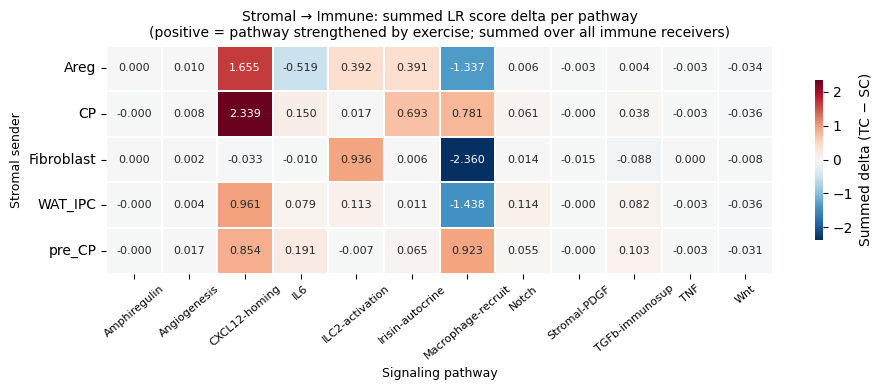

In [15]:
# For each stromal sender, compute summed delta across all immune receivers
STROMAL_SENDERS = ['Areg', 'CP', 'WAT_IPC', 'pre_CP', 'Fibroblast']
IMMUNE_RECEIVERS = ['nILC2', 'Treg', 'M2', 'M1', 'NK', 'NK',
                    'CD4_Memory', 'CD4_Naive', 'CD8_Cytotoxic', 'cDC2', 'cDC1',
                    'Monocyte_Inflammatory', 'Monocyte_Patrolling', 'Mast', 'Neutrophil']
immune_present  = [r for r in set(IMMUNE_RECEIVERS) if r in vwat.obs['cell_state_label'].values]
stromal_present = [s for s in STROMAL_SENDERS    if s in vwat.obs['cell_state_label'].values]

stromal_immune = lr_pivot[
    lr_pivot['sender'].isin(stromal_present) &
    lr_pivot['receiver'].isin(immune_present)
].copy()

# Aggregate: total delta per (sender, pathway)
sender_pathway_delta = (
    stromal_immune
    .groupby(['sender', 'pathway'])['delta_TC_SC']
    .sum()
    .reset_index()
    .pivot(index='sender', columns='pathway', values='delta_TC_SC')
    .fillna(0)
)

vmax_sp = sender_pathway_delta.abs().values.max()
fig, ax = plt.subplots(figsize=(max(8, len(sender_pathway_delta.columns) * 0.8),
                                max(4, len(sender_pathway_delta) * 0.6)))
sns.heatmap(
    sender_pathway_delta,
    ax=ax,
    cmap='RdBu_r',
    center=0,
    vmin=-vmax_sp, vmax=vmax_sp,
    annot=True, fmt='.3f',
    annot_kws={'size': 8},
    linewidths=0.3,
    cbar_kws={'label': 'Summed delta (TC − SC)', 'shrink': 0.7}
)
ax.set_title('Stromal → Immune: summed LR score delta per pathway\n'
             '(positive = pathway strengthened by exercise; summed over all immune receivers)',
             fontsize=10)
ax.set_xlabel('Signaling pathway', fontsize=9)
ax.set_ylabel('Stromal sender', fontsize=9)
ax.tick_params(axis='x', rotation=40, labelsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'stromal_immune_pathway_delta.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# What are the top 15 individual stromal→immune interactions changed by exercise?
top_si = (
    stromal_immune
    .sort_values('delta_TC_SC', ascending=False)
    .head(15)[['sender', 'receiver', 'ligand', 'receptor', 'pathway',
               'SC', 'TC', 'delta_TC_SC']]
)
print('Top 15 stromal→immune interactions strengthened by exercise (TC − SC):')
print(top_si.to_string(index=False))
print()
bottom_si = (
    stromal_immune
    .sort_values('delta_TC_SC', ascending=True)
    .head(10)[['sender', 'receiver', 'ligand', 'receptor', 'pathway',
               'SC', 'TC', 'delta_TC_SC']]
)
print('Top 10 interactions weakened by exercise:')
print(bottom_si.to_string(index=False))

Top 15 stromal→immune interactions strengthened by exercise (TC − SC):
    sender              receiver ligand receptor            pathway       SC       TC  delta_TC_SC
Fibroblast                  Mast   Il33   Il1rl1    ILC2-activation 0.667975 1.291533     0.623558
        CP   Monocyte_Patrolling Cxcl12    Cxcr4      CXCL12-homing 0.838948 1.348740     0.509793
      Areg   Monocyte_Patrolling Cxcl12    Cxcr4      CXCL12-homing 0.512748 0.863182     0.350434
        CP                    M1 Cxcl12    Cxcr4      CXCL12-homing 0.543582 0.889227     0.345645
    pre_CP Monocyte_Inflammatory   Ccl2     Ccr2 Macrophage-recruit 0.900188 1.241355     0.341168
        CP Monocyte_Inflammatory Cxcl12    Cxcr4      CXCL12-homing 0.607723 0.853404     0.245681
      Areg                    M1 Cxcl12    Cxcr4      CXCL12-homing 0.332227 0.569097     0.236871
        CP         CD8_Cytotoxic Cxcl12    Cxcr4      CXCL12-homing 0.422783 0.655605     0.232822
    pre_CP   Monocyte_Patrolling Cxcl1

---

## Section 7: Irisin→integrin score across cell types

Who are the paracrine targets of Areg-derived irisin? Compute Fndc5→Itgb5/Itgb1/Itgav
scores with Areg as sender, all vWAT cell types as receivers, and show the exercise delta.

In [17]:
irisin_pairs = [p for p in valid if p[0] == 'Fndc5']

irisin_scores = lr_pivot[
    (lr_pivot['sender'] == 'Areg') &
    (lr_pivot['ligand'] == 'Fndc5')
].copy()

irisin_scores['lr_label'] = irisin_scores['ligand'] + ' → ' + irisin_scores['receptor']

# Pivot: receiver × lr_label, value = delta
irisin_hm = irisin_scores.pivot_table(
    index='receiver', columns='lr_label', values='delta_TC_SC'
).fillna(0)

# Show top receivers by summed delta
irisin_hm['total_delta'] = irisin_hm.sum(axis=1)
irisin_hm_sorted = irisin_hm.sort_values('total_delta', ascending=False)
print('Receivers with highest irisin signal increase (TC − SC), Areg as sender:')
print(irisin_hm_sorted.head(15).to_string())

Receivers with highest irisin signal increase (TC − SC), Areg as sender:
lr_label             Fndc5 → Itgav  Fndc5 → Itgb1  Fndc5 → Itgb5  total_delta
receiver                                                                     
WAT_IPC                   0.010572       0.028363       0.020695     0.059631
Monocyte_Patrolling       0.010156       0.033800       0.014438     0.058394
pre_CP                    0.008364       0.032967       0.015759     0.057090
vSMC                      0.010224       0.042745       0.002310     0.055279
Pericyte                  0.003052       0.036668       0.009331     0.049051
CD4_Memory                0.003050       0.045834       0.000000     0.048885
CP                        0.006061       0.026683       0.013097     0.045842
Areg                      0.006664       0.022063       0.016296     0.045022
Large_vessel              0.000448       0.037950       0.000000     0.038398
Lymphatic                 0.010665       0.025113       0.001843     

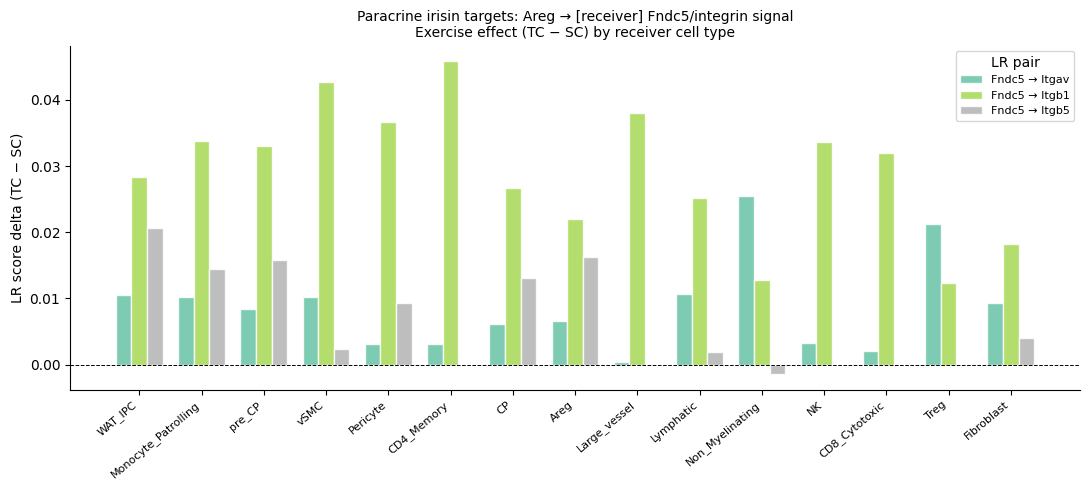

In [18]:
# Bar chart: top 15 receivers of Areg-derived irisin signal, by total delta
top_receivers = irisin_hm_sorted.head(15)
lr_cols = [c for c in top_receivers.columns if c != 'total_delta']

fig, ax = plt.subplots(figsize=(11, 5))
x     = np.arange(len(top_receivers))
cmap  = plt.cm.get_cmap('Set2', len(lr_cols))
width = 0.25

for i, col in enumerate(lr_cols):
    offset = (i - len(lr_cols)/2 + 0.5) * width
    ax.bar(x + offset, top_receivers[col], width,
           label=col, color=cmap(i), alpha=0.85, edgecolor='white')

ax.axhline(0, color='k', linewidth=0.7, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(top_receivers.index, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('LR score delta (TC − SC)')
ax.set_title('Paracrine irisin targets: Areg → [receiver] Fndc5/integrin signal\n'
             'Exercise effect (TC − SC) by receiver cell type',
             fontsize=10)
ax.legend(title='LR pair', fontsize=8, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'irisin_paracrine_targets.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Section 8: Summary

Pull together the CCC findings into an interpretable narrative.

In [19]:
# Summary table: key findings across all sections
summary_rows = [
    (
        'ADAM protease check',
        'Adam10 and Adam17 constitutively expressed in vWAT Areg cells '
        '(~0.10–0.14 mean log-norm, all conditions). Fndc5 triples in TC (0.063) vs SC (0.024).',
        'Substrate availability (Fndc5 mRNA) is rate-limiting, not protease abundance. '
        'Exercise upregulates the substrate; the sheddase is always present.'
    ),
    (
        'Amphiregulin → EGFR',
        'Areg cells are the primary amphiregulin (Areg gene) producers in vWAT. '
        'Egfr is expressed across stromal (CP, WAT_IPC) and immune (Treg, nILC2) states.',
        'Areg cells signal to both progenitors (adipogenesis) and immune cells (tolerance). '
        'Classic tissue-repair EGFR axis.'
    ),
    (
        'ILC2 axis (Il33 → ST2)',
        'Il33 expressed by stromal populations; Il1rl1 (ST2) highest in nILC2. '
        'Exercise effect on this axis determined by LR score delta.',
        'If exercise increases Il33→nILC2 signal, it may drive type-2 immune environment '
        'that suppresses adipose inflammation.'
    ),
    (
        'Irisin paracrine targets',
        'Areg-derived Fndc5 → integrin signal quantified for all vWAT receiver cell types. '
        'Top receivers identified by TC−SC delta.',
        'Identifies which cell types are the paracrine targets of the Areg irisin loop '
        '(beyond autocrine Areg→Areg signaling).'
    ),
    (
        'Stromal→immune communication network',
        'LR scores computed for all stromal sender × immune receiver × 25 LR pairs. '
        'Top exercise-amplified interactions identified per pathway.',
        'Connects the Fndc5/irisin story to the broader immune remodeling observed '
        'with exercise in visceral fat.'
    ),
]

summary_df = pd.DataFrame(summary_rows, columns=['Finding', 'Evidence', 'Interpretation'])
print('NB12 Summary')
print('=' * 80)
for _, row in summary_df.iterrows():
    print(f"\n### {row['Finding']}")
    print(f"Evidence:       {row['Evidence']}")
    print(f"Interpretation: {row['Interpretation']}")

summary_df.to_csv(OUT_DIR / 'nb12_ccc_summary.csv', index=False)
print('\n\nSaved to outputs/nb12_ccc_summary.csv')

NB12 Summary

### ADAM protease check
Evidence:       Adam10 and Adam17 constitutively expressed in vWAT Areg cells (~0.10–0.14 mean log-norm, all conditions). Fndc5 triples in TC (0.063) vs SC (0.024).
Interpretation: Substrate availability (Fndc5 mRNA) is rate-limiting, not protease abundance. Exercise upregulates the substrate; the sheddase is always present.

### Amphiregulin → EGFR
Evidence:       Areg cells are the primary amphiregulin (Areg gene) producers in vWAT. Egfr is expressed across stromal (CP, WAT_IPC) and immune (Treg, nILC2) states.
Interpretation: Areg cells signal to both progenitors (adipogenesis) and immune cells (tolerance). Classic tissue-repair EGFR axis.

### ILC2 axis (Il33 → ST2)
Evidence:       Il33 expressed by stromal populations; Il1rl1 (ST2) highest in nILC2. Exercise effect on this axis determined by LR score delta.
Interpretation: If exercise increases Il33→nILC2 signal, it may drive type-2 immune environment that suppresses adipose inflammation.

###

---

## Concept check

1. **Why use mean_ligand × mean_receptor rather than something more sophisticated?**  
   *(The product captures both halves of the interaction — a strong ligand source paired with
   a strong receptor target produces a high score. More sophisticated methods (NicheNet, LIANA)
   add pathway-level weighting and permutation testing, but the core signal is the same.
   With N=3 per group, permutation testing is underpowered anyway.)*

2. **ADAM10 expression doesn't change with exercise. Does that weaken the Fndc5 story?**  
   *(No — it strengthens it. Constitutive ADAM expression means the cleavage machinery is
   always ready. The biology is regulated at the substrate level: more Fndc5 mRNA → more
   Fndc5 protein on the membrane → more irisin shed, same rate of cleavage per molecule.
   Exercise-regulated substrate + constitutive sheddase is the canonical ADAM biology.)*

3. **The Areg→Treg amphiregulin signal: is this interesting?**  
   *(Yes. Adipose Tregs are a specialized population that maintain metabolic homeostasis.
   Amphiregulin from Areg stromal cells activating Tregs via EGFR would be a novel
   stromal→Treg communication loop in the exercise context. This is a testable wet-lab
   hypothesis: do exercise-conditioned Areg-CM (conditioned media) expand Tregs in vitro?)*